<a href="https://colab.research.google.com/github/ankur-b17/MAS-AI/blob/main/MAS_AI_LangGraph_v2(3_5_flash).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# #Install Dependencies

# !pip install -q \
#    google-cloud-storage \
#    google-generativeai \
#    langchain \
#    langchain-google-genai \
#    langgraph \
#    torch torchvision \
#    Pillow pandas scikit-learn python-dotenv \
#    langchain_google_genai

In [ ]:
#  !pip install langchain_google_genai

In [ ]:
# pip install langchain-google-vertexai

In [ ]:
#   !pip install google-cloud-aiplatform

In [ ]:
# Authenticate user
from google.colab import auth
auth.authenticate_user()

In [ ]:
# This maps your Colab Secret to the environment variable your code expects
from google.colab import userdata
import os

os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')

In [ ]:
# GCP Configuration

import os
from dotenv import load_dotenv
load_dotenv()

from google.cloud import storage

# set project info
PROJECT_ID  = "mas-ai-493121"
BUCKET_NAME = "mas-dr-100"
LOCATION="us-south1"

FOLDER_PREFIXES = [
    "DR_Dataset/0_No_DR/",
    "DR_Dataset/1_Mild/",
    "DR_Dataset/2_Moderate/",
    "DR_Dataset/3_Severe/",
]

GROUND_TRUTH_MAP = {
    "DR_Dataset/0_No_DR/"    : "NO_DR",
    "DR_Dataset/1_Mild/"     : "MI_DR",
    "DR_Dataset/2_Moderate/" : "MO_DR",
    "DR_Dataset/3_Severe/"   : "SE_DR",
}

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png"}
VALID_DR_LABELS  = {"NO_DR", "MI_DR", "MO_DR", "SE_DR"}

#Initialize gcs client
gcs_client = storage.Client(project=PROJECT_ID)
bucket     = gcs_client.bucket(BUCKET_NAME)

print(f"GCS connected → gs://{BUCKET_NAME} (project: {PROJECT_ID})")

GCS connected → gs://mas-dr-100 (project: mas-ai-493121)


In [ ]:
# accessing the files in GCS
from google.cloud import storage

gcs_client = storage.Client(project=PROJECT_ID)
bucket = gcs_client.bucket(BUCKET_NAME)

#blobs = gcs_client.list_blobs(BUCKET_NAME)
#for blob in blobs:
#    print(blob.name)

count = len(list(gcs_client.list_blobs(BUCKET_NAME)))
print("Total images in Bucket:",count)

Total images in Bucket: 1000


In [ ]:
#  Defining the imageclass state schema

from typing import TypedDict, List, Dict, Any, Optional

class ImageClass(TypedDict):
    """
    Shared state that flows through every node in the LangGraph pipeline.

    Core fields (spec-required):
        img_id                : filename of the current image, e.g. '1299_left.jpg'
        ground_truth          : true DR label derived from GCS folder, e.g. 'NO_DR'
        gemini_classification : DR label predicted by Gemini Vision, e.g. 'NO_DR'

    Pipeline fields (inter-agent data flow):
        all_images            : list of lightweight {img_id, ground_truth, blob_name} dicts
                                (NO base64 — images are fetched one at a time)
        current_index         : index into all_images for the current loop iteration
        image_b64             : raw base64 image bytes for the current image (transient, not stored in all_images)
        preprocessed_b64      : preprocessed base64 image bytes (after resize/normalise)
        results               : accumulated list of {img_id, ground_truth, gemini_classification}
        df_json               : JSON string of the final results DataFrame
    """
    # ── Spec-required fields
    img_id               : str
    ground_truth         : str
    gemini_classification: str
    # ── Pipeline fields
    all_images           : List[Dict[str, Any]]   # lightweight metadata only, no base64
    current_index        : int
    image_b64            : str                    # transient: current image only
    preprocessed_b64     : str
    results              : List[Dict[str, str]]
    df_json              : str
    analysis_metrics     : Dict[str, Any]   # populated by analyzer_agent_node
    nlp_explanation      : str              # populated by output_agent_node

print(" ImageClass state schema defined")

 ImageClass state schema defined


In [ ]:
# Agent 1: Input Agent Node

import base64
import time
import traceback
from pathlib import PurePosixPath
from google.api_core import retry as api_retry

_GCS_RETRY = api_retry.Retry(deadline=120)   # 2-min deadline, exponential back-off

def input_agent_node(state: ImageClass) -> dict:
    """
    Input Agent — LangGraph node.

    Reads  : state['all_images'], state['current_index']
    Writes : state['all_images'], state['img_id'], state['ground_truth'], state['image_b64']

    Hardened:
      - GCS discovery and download both use google-api-core retry with 2-min deadline
      - Download elapsed time is logged; anything over 30 s triggers a warning
      - base64 encoding is done inside a try/except so corrupt blobs don't kill the run
    """
    all_images = state["all_images"]

    # ── Discover image metadata (first call only) ────────────────────────────
    if not all_images:
        print("[Input Agent]:  Discovering images from GCS (metadata only) ...")
        discovered = []
        for prefix in FOLDER_PREFIXES:
            blobs = list(bucket.list_blobs(prefix=prefix))
            for blob in blobs:
                path = blob.name
                ext  = PurePosixPath(path).suffix.lower()
                if ext not in VALID_EXTENSIONS:
                    continue
                img_id = PurePosixPath(path).name
                ground_truth = next(
                    (label for folder, label in GROUND_TRUTH_MAP.items() if folder in path),
                    None,
                )
                if ground_truth is None:
                    print(f"[Input Agent]:  No GT mapping for: {path}")
                    continue
                discovered.append({"img_id": img_id, "ground_truth": ground_truth, "blob_name": blob.name})
                #break
        all_images = discovered
        print(f"[Input Agent]:  Discovered {len(all_images)} images")

    # ── Fetch current image ──────────────────────────────────────────────────
    idx    = state["current_index"]
    record = all_images[idx]
    print(f"[Input Agent]:  Fetching {idx + 1}/{len(all_images)}: {record['img_id']}")

    t0 = time.perf_counter()
    try:
        blob      = bucket.blob(record["blob_name"])
        raw_bytes = blob.download_as_bytes(retry=_GCS_RETRY, timeout=90)
    except Exception as exc:
        raise RuntimeError(
            f"[Input Agent] GCS download failed for {record['blob_name']}: {exc}"
        ) from exc

    elapsed = time.perf_counter() - t0
    if elapsed > 30:
        print(f"[Input Agent]:   Slow download: {record['img_id']} took {elapsed:.1f}s")
    else:
        print(f"[Input Agent]:  Downloaded {record['img_id']} in {elapsed:.2f}s ({len(raw_bytes)/1024:.1f} KB)")

    image_b64 = base64.b64encode(raw_bytes).decode()

    return {
        "all_images"  : all_images,
        "img_id"      : record["img_id"],
        "ground_truth": record["ground_truth"],
        "image_b64"   : image_b64,
    }

print("Input Agent node defined (hardened)")


Input Agent node defined (hardened)


In [ ]:
# Agent 2: Preprocessing Agent Node

import io
import time
import contextlib
from PIL import Image as PilImage      # aliased — avoids collision with LangChain's Image type
from PIL import ImageFile
import torchvision.transforms as T

# Allow PIL to load truncated / partially-downloaded files
ImageFile.LOAD_TRUNCATED_IMAGES = True

_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

@contextlib.contextmanager
def _timeout_guard(img_id: str, label: str, limit_s: float = 30.0):
    """Emit a warning if a block takes longer than limit_s seconds."""
    t0 = time.perf_counter()
    yield
    elapsed = time.perf_counter() - t0
    if elapsed > limit_s:
        print(f"[Preprocessing Agent]:   SLOW OP — {label} for {img_id} took {elapsed:.1f}s (>{limit_s}s)")

def preprocessing_agent_node(state: ImageClass) -> dict:
    """
    Preprocessing Agent — LangGraph node.

    Reads  : state['image_b64']        (raw bytes, base64-encoded)
    Writes : state['preprocessed_b64']  (224x224 JPEG, base64-encoded)

    Hardened against:
      - Name collision: PIL imported as PilImage to avoid LangChain overwrite
      - Corrupt / truncated images (LOAD_TRUNCATED_IMAGES + eager .load())
      - Memory leaks (explicit BytesIO.close() + PilImage.close())
      - Silent hangs (per-step timing with threshold warnings)
      - Non-RGB modes (RGBA, P, L, CMYK) that crash ToTensor
    """
    img_id    = state["img_id"]
    image_b64 = state["image_b64"]

    t_start = time.perf_counter()
    #print(f"[Preprocessing Agent]:  {img_id}  (b64 len={len(image_b64):,})")

    # ── 1. Decode base64 ────────────────────────────────────────────────────
    with _timeout_guard(img_id, "base64 decode"):
        try:
            raw = base64.b64decode(image_b64)
        except Exception as exc:
            raise RuntimeError(
                f"[Preprocessing Agent] base64 decode failed for {img_id}: {exc}"
            ) from exc

    # ── 2. Open image ────────────────────────────────────────────────────────
    raw_buf = io.BytesIO(raw)
    pil = None
    with _timeout_guard(img_id, "PIL open"):
        try:
            pil = PilImage.open(raw_buf)   # PilImage — not the overwritten Image
            pil.load()                     # force full decode eagerly
        except Exception as exc:
            raw_buf.close()
            raise RuntimeError(
                f"[Preprocessing Agent] PIL open failed for {img_id}: {exc}"
            ) from exc

    print(f"[Preprocessing Agent]:   {img_id} original size={pil.size} mode={pil.mode}")

    # ── 3. Normalise colour mode ─────────────────────────────────────────────
    with _timeout_guard(img_id, "RGB convert"):
        if pil.mode != "RGB":
            print(f"[Preprocessing Agent]:   converting {pil.mode}→RGB for {img_id}")
            converted = pil.convert("RGB")
            pil.close()
            pil = converted

    # ── 4. Resize ────────────────────────────────────────────────────────────
    with _timeout_guard(img_id, "resize"):
        resized = pil.resize((224, 224), PilImage.LANCZOS)
    pil.close()

    # ── 5. torchvision transform (tensor) ────────────────────────────────────
    with _timeout_guard(img_id, "torchvision transform", limit_s=20.0):
        try:
            _ = _transform(resized)
        except Exception as exc:
            # Non-fatal: Gemini only needs the JPEG bytes
            print(f"[Preprocessing Agent]:  torchvision transform failed for {img_id}: {exc}")

    # ── 6. Encode as JPEG base64 ─────────────────────────────────────────────
    out_buf = io.BytesIO()
    with _timeout_guard(img_id, "JPEG encode"):
        resized.save(out_buf, format="JPEG", quality=85, optimize=True)
    resized.close()

    preprocessed_b64 = base64.b64encode(out_buf.getvalue()).decode()
    out_buf.close()
    raw_buf.close()

    elapsed = time.perf_counter() - t_start
    print(f"[Preprocessing Agent]:  {img_id} → 224×224 JPEG "
          f"(out b64 len={len(preprocessed_b64):,}) in {elapsed:.2f}s")

    return {"preprocessed_b64": preprocessed_b64}

print(" Preprocessing Agent node defined (hardened)")


 Preprocessing Agent node defined (hardened)


In [ ]:

#from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_google_vertexai import ChatVertexAI
import time

# pip install langchain-google-vertexai


# ----------------------------
# Config
# ----------------------------

VALID_DR_LABELS = ["NO_DR", "MI_DR", "MO_DR", "SE_DR"]

# llm = ChatGoogleGenerativeAI(
#     model="gemini-3.5-flash",
#     project=PROJECT_ID,
#     location="us-central1", # changed  to  us-central1
#     temperature=1.0,
#     max_output_tokens=256,
#     request_timeout=30,
# )

llm = ChatVertexAI(
    model="gemini-3.5-flash",
    project="mas-ai-493121",
    location="global",
    max_output_tokens=256,
    request_timeout=30,
    # For Gemini 3.5+, use extra_params for the new thinking logic if needed
    extra_params={"thinking_level": "high"}
)
# ----------------------------
# Prompt
# ----------------------------

_CLASSIFY_PROMPT = """
You are a medical AI assistant specialised in Diabetic Retinopathy (DR) grading.
Examine the retinal fundus image and classify it into EXACTLY ONE class:
  NO_DR  — No Diabetic Retinopathy (normal, healthy retina)
  MI_DR  — Mild Diabetic Retinopathy
  MO_DR  — Moderate Diabetic Retinopathy
  SE_DR  — Severe Diabetic Retinopathy
Rules:
- Base classification ONLY on visual features (microaneurysms, haemorrhages,hard exudates, cotton-wool spots, neovascularisation).
- Do NOT guess. You MUST use the image for inference.
- Respond with ONLY the label: NO_DR  MI_DR  MO_DR  SE_DR - nothing else.
"""

# ----------------------------
# Retry config
# ----------------------------

_MAX_RETRIES = 3
_RETRY_BACKOFF = [2, 5, 10]


# ----------------------------
# Robust label parser
# ----------------------------

def extract_label(raw_text: str):
    if not raw_text:
        return None

    raw = raw_text.strip().upper()

    # normalize common formatting issues
    raw = raw.replace("\n", "").replace(" ", "").replace("-", "").replace("_", "")

    # direct normalized mapping
    NORMALIZED_MAP = {
        "NODR": "NO_DR",
        "MIDR": "MI_DR",
        "MODR": "MO_DR",
        "SEDR": "SE_DR",
    }

    if raw in NORMALIZED_MAP:
        return NORMALIZED_MAP[raw]

    # fallback match
    for label in VALID_DR_LABELS:
        if raw == label.replace("_", ""):
            return label

    return None


# ----------------------------
# Classifier Node
# ----------------------------

def classifier_agent_node(state: ImageClass) -> dict:
    img_id = state["img_id"]
    preprocessed_b64 = state["preprocessed_b64"]

    last_exc = None

    for attempt in range(1, _MAX_RETRIES + 1):
        t0 = time.perf_counter()

        try:
            response = llm.invoke ( [
                 {
                     "role" : "user" ,
                     "content" : [
                          { "type" : "text" , "text" : _CLASSIFY_PROMPT } ,
                          {
                             "type" : "image_url" ,
                             "image_url" : {
                                 "url" : f"data:image/jpeg;base64,{ preprocessed_b64 }"
                             } ,
                          } ,
                      ] ,
                  }
             ] )
            elapsed = time.perf_counter () - t0

            # --- FIXED RESPONSE EXTRACTION ---
            raw_output = response.content or ""
            if isinstance(raw_output, list):
                # If it's a list of parts, extract text components and join them
                raw_output = "".join([part.get("text", "") if isinstance(part, dict) else str(part) for part in raw_output])
            # ----------------------------------

            finish_reason = response.response_metadata.get ( "finish_reason" )

            # Now .strip() will safely work on the processed string
            if not raw_output.strip ( ) :
                raise ValueError ( f"Empty output (finish={ finish_reason })" )

            if finish_reason == "MAX_TOKENS":
                raise ValueError("Truncated output (MAX_TOKENS)")

            # parse label
            label = extract_label(raw_output)

            if not label:
                raise ValueError(f"Unrecognised label: '{raw_output}'")

            print(f"[Classifier Agent]: {img_id} → {label} "
                  f"(attempt {attempt}, {elapsed:.1f}s)")

            return {"gemini_classification": label}

        except Exception as exc:
            last_exc = exc
            wait = _RETRY_BACKOFF[attempt - 1] if attempt <= len(_RETRY_BACKOFF) else 15

            print(f"[Classifier Agent]: attempt {attempt}/{_MAX_RETRIES} failed for {img_id}: {exc}")

            if attempt < _MAX_RETRIES:
                print(f"[Classifier Agent]: retrying in {wait}s ...")
                time.sleep(wait)

    raise RuntimeError(
        f"[Classifier Agent] All {_MAX_RETRIES} attempts failed for {img_id}"
    ) from last_exc


print("Classifier Agent node ready ")

/tmp/ipykernel_9281/2123162728.py:23: DeprecationWarning: Use [`ChatGoogleGenerativeAI`][langchain_google_genai.ChatGoogleGenerativeAI] instead.
  llm = ChatVertexAI(


Classifier Agent node ready 


/tmp/ipykernel_9281/2123162728.py:23: UserWarning: WARNING! request_timeout is not default parameter.
                request_timeout was transferred to model_kwargs.
                Please confirm that request_timeout is what you intended.
  llm = ChatVertexAI(
/tmp/ipykernel_9281/2123162728.py:23: UserWarning: WARNING! extra_params is not default parameter.
                extra_params was transferred to model_kwargs.
                Please confirm that extra_params is what you intended.
  llm = ChatVertexAI(


In [ ]:
#Agent 4: Tabular Agent Node

# Receives: ImageClass state
# Reads: state['img_id'], state['ground_truth'], state['gemini_classification'], state['results']
# Returns: updated results (appended) and current_index (incremented)

import pandas as pd

def tabular_agent_node(state: ImageClass) -> dict:
    """
    Tabular Agent — LangGraph node.

    Reads  : state['img_id']                (set by Input Agent)
             state['ground_truth']          (set by Input Agent)
             state['gemini_classification'] (set by Classifier Agent)
             state['results']               (accumulated list so far)
             state['current_index']         (loop counter)
    Writes : state['results']               (appends the new row)
             state['current_index']         (incremented by 1)

    On each call appends one row. The router node decides whether to loop
    back to input_agent or proceed to the analyzer based on current_index.
    """
    #  Read the three fields  from shared state
    img_id                = state["img_id"]
    ground_truth          = state["ground_truth"]
    gemini_classification = state["gemini_classification"]
    results               = list(state["results"])      # copy to avoid mutation
    current_index         = state["current_index"]

    # Append new row
    results.append({
        "img_id"               : img_id,
        "ground_truth"         : ground_truth,
        "gemini_classification": gemini_classification,
    })

    total = len(state["all_images"])
    print(f"[Tabular Agent]: Recorded {img_id} | GT={ground_truth} | Pred={gemini_classification} (row {len(results)}/{total})")

    # Write updated results and incremented index back into state
    return {
        "results"      : results,
        "current_index": current_index + 1,
    }

print(" Tabular Agent node defined")

 Tabular Agent node defined


In [ ]:
##  Agent 5: Analyzer Agent Node

# Receives: ImageClass state
# Reads:    state['results']
# Returns:  updated df_json + analysis_metrics (for the Output Agent)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import pandas as pd

def analyzer_agent_node(state: ImageClass) -> dict:
    """
    Analyzer Agent — computes evaluation metrics from model predictions
    and stores them in state['analysis_metrics'] for the Output Agent.
    """
    results = state["results"]
    df      = pd.DataFrame(results)

    y_true = df["ground_truth"]
    y_pred = df["gemini_classification"]
    labels = sorted(VALID_DR_LABELS)

    # ── Core metrics ────────────────────────────────────────────────────────
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    cm  = confusion_matrix(y_true, y_pred, labels=labels)

    # Per-class precision / recall / f1
    prec_per_class = precision_score(y_true, y_pred, labels=labels,
                                     average=None, zero_division=0)
    rec_per_class  = recall_score(y_true, y_pred, labels=labels,
                                  average=None, zero_division=0)
    f1_per_class   = f1_score(y_true, y_pred, labels=labels,
                              average=None, zero_division=0)

    per_class = {
        label: {
            "precision": round(float(p), 4),
            "recall"   : round(float(r), 4),
            "f1_score" : round(float(f), 4),
            "support"  : int((y_true == label).sum()),
        }
        for label, p, r, f in zip(labels, prec_per_class, rec_per_class, f1_per_class)
    }

    cm_dict = {
        label: {pred_label: int(cm[i][j]) for j, pred_label in enumerate(labels)}
        for i, label in enumerate(labels)
    }

    analysis_metrics = {
        "total_samples"  : len(df),
        "accuracy"       : round(float(acc), 4),
        "weighted_f1"    : round(float(f1), 4),
        "per_class"      : per_class,
        "confusion_matrix": cm_dict,
        "class_report_str": classification_report(y_true, y_pred, labels=labels, zero_division=0),
    }

    # ── Console summary ─────────────────────────────────────────────────────
    print("\n FINAL RESULTS")
    print(f"Total samples : {len(df)}")
    print(f"Accuracy      : {acc:.4f}")
    print(f"F1 Score      : {f1:.4f}")
    print("\n Classification Report:")
    print(analysis_metrics["class_report_str"])
    print("\n Confusion Matrix:")
    #print(pd.DataFrame(cm, index=labels, columns=labels))

    return {
        "df_json"         : df.to_json(orient="records"),
        "analysis_metrics": analysis_metrics,
    }

print(" Analyzer Agent node defined")


 Analyzer Agent node defined


In [ ]:
## Agent 6: Output Agent Node (NLP Explanation via Gemini LLM)

# Receives: ImageClass state
# Reads:    state['analysis_metrics']
# Returns:  state['nlp_explanation'] — a short, concise NLP summary

#from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_google_vertexai import ChatVertexAI
import json

#   initialise a fresh one for text generation
# _output_llm = ChatGoogleGenerativeAI(
#     model="gemini-3.5-flash",
#     project=PROJECT_ID,
#     location="us-central1", # changed to us-central1
#     temperature=0.5,
#     max_output_tokens=1200,
# )

_output_llm = ChatVertexAI(
    model="gemini-3.5-flash",
    project= "mas-ai-493121",
    location="global",
    max_output_tokens=1200,
    request_timeout=30,
    # For Gemini 3.5+, use extra_params for the new thinking logic if needed
    extra_params={"thinking_level": "medium"}
)

_OUTPUT_PROMPT_TEMPLATE = """You are a clinical AI assistant. Below are the evaluation metrics from a
Diabetic Retinopathy (DR) classification pipeline that used Gemini Vision to
predict DR severity on retinal fundus images.

Metrics (JSON):
{metrics_json}

Write a SHORT, CONCISE plain-English explanation (3–5 sentences maximum) that:
1. States the overall model accuracy and F1 score.
2. Highlights which DR severity class the model handles best and which it struggles with most.
3. Notes any notable confusion between classes from the confusion matrix.
4. Closes with one sentence on clinical implications or next steps.
5. New Line after 25 words

Do NOT use bullet points or headers — output flowing prose only.
"""

def output_agent_node(state: ImageClass) -> dict:
    """
    Output Agent — uses Gemini LLM to generate a concise NLP explanation
    of the analysis metrics produced by the Analyzer Agent.
    """
    metrics = state["analysis_metrics"]

    # Compact JSON for the prompt (drop the verbose class_report_str)
    prompt_metrics = {k: v for k, v in metrics.items() if k != "class_report_str"}
    metrics_json   = json.dumps(prompt_metrics, indent=2)

    prompt = _OUTPUT_PROMPT_TEMPLATE.format(metrics_json=metrics_json)

    response = _output_llm.invoke([{"role": "user", "content": prompt}])
    explanation = response.content.strip()

    print("\n" + "═" * 65)
    print("  OUTPUT AGENT — NLP Explanation")
    print("═" * 65)
    print(explanation)
    print("═" * 65 + "\n")

    return {"nlp_explanation": explanation}

print(" Output Agent node defined")


/tmp/ipykernel_9281/3795418459.py:20: DeprecationWarning: Use [`ChatGoogleGenerativeAI`][langchain_google_genai.ChatGoogleGenerativeAI] instead.
  _output_llm = ChatVertexAI(


 Output Agent node defined


/tmp/ipykernel_9281/3795418459.py:20: UserWarning: WARNING! request_timeout is not default parameter.
                request_timeout was transferred to model_kwargs.
                Please confirm that request_timeout is what you intended.
  _output_llm = ChatVertexAI(
/tmp/ipykernel_9281/3795418459.py:20: UserWarning: WARNING! extra_params is not default parameter.
                extra_params was transferred to model_kwargs.
                Please confirm that extra_params is what you intended.
  _output_llm = ChatVertexAI(


In [ ]:
# Router: Loop Control

from typing import Literal

def route_after_tabular(state: ImageClass) -> Literal["input_agent_node", "analyzer_agent_node"]:
    """
    Router — reads state['current_index'] and state['all_images'].
    Routes back to input_agent_node if more images remain,
    or to analyzer_agent_node when all images have been processed.
    """
    if state["current_index"] < len(state["all_images"]):
        remaining = len(state["all_images"]) - state["current_index"]
        print(f"\n[Router]:   {remaining} image(s) remaining → looping to Input Agent")
        return "input_agent_node"
    else:
        print("[Router]: All images processed → proceeding to Analyzer Agent")
        return "analyzer_agent_node"

print(" Router defined")

 Router defined


In [ ]:
# Build the LangGraph
# Nodes are wired using ImageClass as the graph's state_schema.
# LangGraph uses the schema to validate state updates and merge returned dicts automatically.

from langgraph.graph import StateGraph, START, END

# --------------------------------Build graph with ImageClass as the state schema -----------------
builder = StateGraph(ImageClass)

#--------------------------------Register all 5 agent nodes ---------------------------------------
builder.add_node("input_agent_node",        input_agent_node)
builder.add_node("preprocessing_agent_node", preprocessing_agent_node)
builder.add_node("classifier_agent_node",   classifier_agent_node)
builder.add_node("tabular_agent_node",      tabular_agent_node)
builder.add_node("analyzer_agent_node",     analyzer_agent_node)
builder.add_node("output_agent_node",     output_agent_node)

# -------------------------------- Wire the sequential edges --------------------------------------
builder.add_edge(START,                       "input_agent_node")
builder.add_edge("input_agent_node",          "preprocessing_agent_node")
builder.add_edge("preprocessing_agent_node",  "classifier_agent_node")
builder.add_edge("classifier_agent_node",     "tabular_agent_node")

# -------------------------------- Conditional edge: loop or finish --------------------------------
builder.add_conditional_edges(
    "tabular_agent_node",
    route_after_tabular,
    {
        "input_agent_node"   : "input_agent_node",
        "analyzer_agent_node": "analyzer_agent_node",
    },
)
builder.add_edge("analyzer_agent_node", "output_agent_node")
builder.add_edge("output_agent_node",   END)

# --------------------------------Compile -----------------------------------------------------------
dr_graph = builder.compile()

print("LangGraph defined")

LangGraph defined


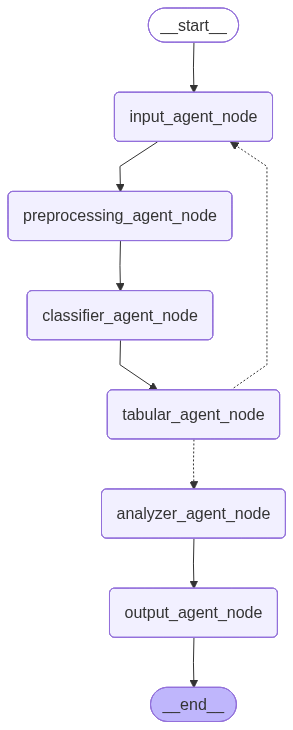

In [ ]:
from IPython.display import Image, display
display(Image(dr_graph.get_graph().draw_mermaid_png()))

In [ ]:
# Run the MAS-AI system Pipeline

import time

print("\n" + "═" * 65)
print("   MAS-AI System for DR Classification  — Pipeline Started")
print("═" * 65 + "\n")

# ── Initial ImageClass state ──────────────────────────────────────────────────
initial_state: ImageClass = {
    # Spec-required fields
    "img_id"               : "",
    "ground_truth"         : "",
    "gemini_classification": "",
    # Pipeline fields
    "all_images"           : [],   # input_agent discovers metadata on first call
    "current_index"        : 0,    # starts at 0, tabular_agent increments
    "image_b64"            : "",   # input_agent updates this
    "preprocessed_b64"     : "",   # preprocess_agent updates this
    "results"              : [],   # tabular_agent appends to this
    "df_json"              : "",
    "analysis_metrics"     : {},   # populated by analyzer_agent_node
    "nlp_explanation"      : "",
}
start_time = time.time()

final_state = dr_graph.invoke(initial_state)

end_time = time.time()
total_time = (end_time - start_time)/ 60


print("\n" + "═" * 65)
print(" Pipeline complete")
print(f"Total Execution Time: {total_time:.2f} minutes")
print("═" * 65)

Streaming output truncated to the last 5000 lines.
[Preprocessing Agent]:  43235_left.jpg → 224×224 JPEG (out b64 len=10,532) in 0.02s
[Classifier Agent]: 43235_left.jpg → NO_DR (attempt 1, 2.3s)
[Tabular Agent]: Recorded 43235_left.jpg | GT=MI_DR | Pred=NO_DR (row 383/1000)

[Router]:   617 image(s) remaining → looping to Input Agent
[Input Agent]:  Fetching 384/1000: 43235_right.jpg
[Input Agent]:  Downloaded 43235_right.jpg in 0.28s (246.8 KB)
[Preprocessing Agent]:   43235_right.jpg original size=(1024, 1021) mode=RGB
[Preprocessing Agent]:  43235_right.jpg → 224×224 JPEG (out b64 len=9,216) in 0.02s
[Classifier Agent]: 43235_right.jpg → NO_DR (attempt 1, 2.9s)
[Tabular Agent]: Recorded 43235_right.jpg | GT=MI_DR | Pred=NO_DR (row 384/1000)

[Router]:   616 image(s) remaining → looping to Input Agent
[Input Agent]:  Fetching 385/1000: 43291_left.jpg
[Input Agent]:  Downloaded 43291_left.jpg in 0.21s (240.2 KB)
[Preprocessing Agent]:   43291_left.jpg original size=(1023, 1018) mode=

In [ ]:
# The final image status

print("Final ImageClass state fields:")
print(f"  img_id                : {final_state['img_id']}")
print(f"  ground_truth          : {final_state['ground_truth']}")
print(f"  gemini_classification : {final_state['gemini_classification']}")
print(f"  current_index         : {final_state['current_index']}")
print(f"  results rows          : {len(final_state['results'])}")

Final ImageClass state fields:
  img_id                : 9951_right.jpg
  ground_truth          : SE_DR
  gemini_classification : MO_DR
  current_index         : 1000
  results rows          : 1000


In [ ]:
results_df = pd.read_json(final_state["df_json"], orient="records")
results_df["correct"] = results_df["ground_truth"] == results_df["gemini_classification"]

print(results_df[["img_id", "ground_truth", "gemini_classification", "correct"]].head())
print(f"\nAccuracy: {results_df['correct'].mean()*100:.1f}% "
      f"({results_df['correct'].sum()}/{len(results_df)} correct)")

            img_id ground_truth gemini_classification  correct
0  11301_right.jpg        NO_DR                 NO_DR     True
1  11305_right.jpg        NO_DR                 NO_DR     True
2   11310_left.jpg        NO_DR                 MO_DR    False
3  11310_right.jpg        NO_DR                 MO_DR    False
4  11445_right.jpg        NO_DR                 NO_DR     True

Accuracy: 32.8% (328/1000 correct)


/tmp/ipykernel_9281/1775248167.py:1: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  results_df = pd.read_json(final_state["df_json"], orient="records")


In [ ]:
results_df.to_csv("dr_classification_results.csv", index=False)
print("Saved: dr_classification_results.csv")

Saved: dr_classification_results.csv


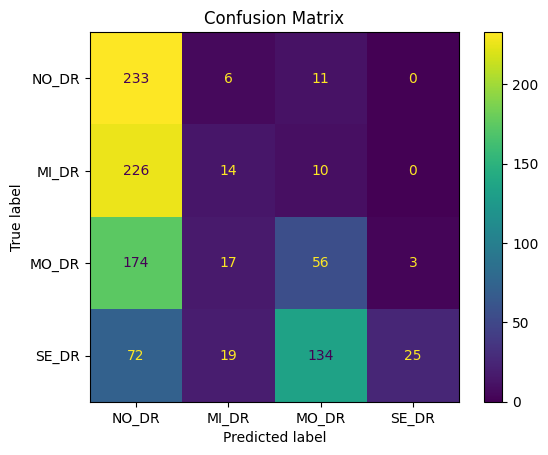

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Load  CSV
df = pd.read_csv("dr_classification_results.csv")

labels = ["NO_DR", "MI_DR", "MO_DR", "SE_DR"]

# Confusion matrix
cm = confusion_matrix(
    df["ground_truth"],
    df["gemini_classification"],
    labels=labels
)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

